In [1]:
from matplotlib import pyplot as plt
import sys
sys.path.append('..')
from csv_handling import load_csv

In [3]:
ages = list(range(21,39))

agefiles = {}
for age in ages:
    agefiles[age] = load_csv(f'sta{age}_props_Table.csv',keycol='Segment')


In [48]:
regions = []
with open('labelnames.txt') as fp:
    for line in fp.readlines():
        parts = line.split('\t')
        regions.append(parts[1].replace('_',' '))

In [49]:
regions

['Clear Label',
 'Precentral L',
 'Precentral R',
 'Frontal Sup L',
 'Frontal Sup R',
 'Frontal Sup Orb L',
 'Frontal Sup Orb R',
 'Frontal Mid L',
 'Frontal Mid R',
 'Frontal Mid Orb L',
 'Frontal Mid Orb R',
 'Frontal Inf Oper L',
 'Frontal Inf Oper R',
 'Frontal Inf Tri L',
 'Frontal Inf Tri R',
 'Frontal Inf Orb L',
 'Frontal Inf Orb R',
 'Rolandic Oper L',
 'Rolandic Oper R',
 'Supp Motor Area L',
 'Supp Motor Area R',
 'Olfactory L',
 'Olfactory R',
 'Frontal Sup Medial L',
 'Frontal Sup Medial R',
 'Frontal Med Orb L',
 'Frontal Med Orb R',
 'Rectus L',
 'Rectus R',
 'Insula L',
 'Insula R',
 'Cingulum Ant L',
 'Cingulum Ant R',
 'Cingulum Mid L',
 'Cingulum Mid R',
 'Cingulum Post L',
 'Cingulum Post R',
 'Hippocampus L',
 'Hippocampus R',
 'ParaHippocampal L',
 'ParaHippocampal R',
 'Amygdala L',
 'Amygdala R',
 'Calcarine L',
 'Calcarine R',
 'Cuneus L',
 'Cuneus R',
 'Lingual L',
 'Lingual R',
 'Occipital Sup L',
 'Occipital Sup R',
 'Occipital Mid L',
 'Occipital Mid R',
 '

In [50]:
len(regions)

127

In [96]:
selected_region =  'Amygdala R' #'Internal Capsule R' 
# selected_region =  'CorpusCallosum' # 

In [97]:
agefiles[21][selected_region]._fields

('Segment',
 'Surface_area__mm2_',
 'Number_of_voxels__voxels_',
 'Volume__mm3_',
 'Volume__cm3_',
 'Minimum',
 'Maximum',
 'Mean',
 'Median',
 'Standard_Deviation')

In [98]:
colname = 'Volume__mm3_'

In [99]:
bilateral = selected_region[-1]=='L' or selected_region[-1]=='R'

In [100]:
if bilateral:
    selrgns = [selected_region[:-1]+'L', selected_region[:-1]+'R']
else:
    selrgns = [selected_region]

In [101]:
data = {}
for rgn in selrgns:
    data[rgn] = [
        float(getattr(agefiles[age][rgn],colname)) 
        for age in ages]

Text(0.5, 1.0, 'Volume__mm3_ against age')

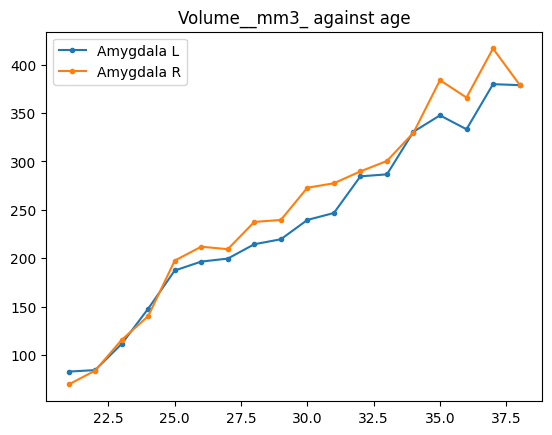

In [102]:
for rgn in selrgns:
    plt.plot(ages,data[rgn],'.-')
plt.legend(selrgns)
plt.title(f'{colname} against age')